In [1]:
# Install necessary libraries
!pip install opencv-python tensorflow_hub matplotlib

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the pre-trained SSD MobileNet V2 model from TensorFlow Hub
print("Loading model...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1")
print("Model loaded successfully!")

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Loading model...
Model loaded successfully!


62656/62656 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


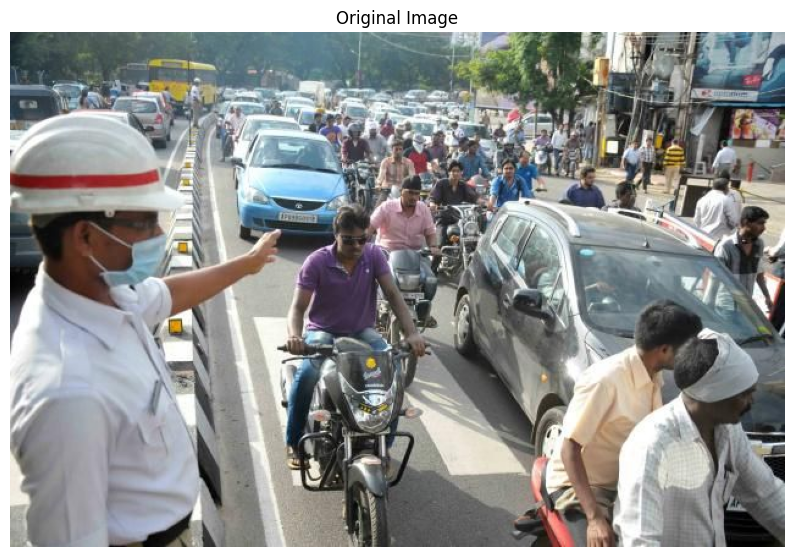

In [12]:
# Function to load an image from a URL and convert it to the right format
def load_image_from_url(image_url):
    image_path = tf.keras.utils.get_file(origin=image_url)
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_np = np.array(image_rgb)
    return image_np

# Sample image URL
image_url = "https://i.pinimg.com/736x/95/2c/5c/952c5c534d3fede548b6578fdc467979.jpg"
image_np = load_image_from_url(image_url)

# Display the loaded image
plt.figure(figsize=(10, 8))
plt.imshow(image_np)
plt.axis('off')
plt.title('Original Image')
plt.show()

In [13]:
input_tensor = tf.convert_to_tensor(image_np)
input_tensor = input_tensor[tf.newaxis, ...]

# Perform inference
result = detector(input_tensor)

# Extract detection results
result = {key:value.numpy() for key,value in result.items()}

# Extract and flatten the results for a single image from the batch
boxes = result['detection_boxes'][0]  # Shape becomes (N_detections, 4)
scores = result['detection_scores'][0] # Shape becomes (N_detections,)
class_ids = result['detection_classes'][0] # Shape becomes (N_detections,)
num_detections = int(result['num_detections'][0]) # Convert to scalar integer

print(f"Detected {num_detections} objects.")

Detected 100 objects.


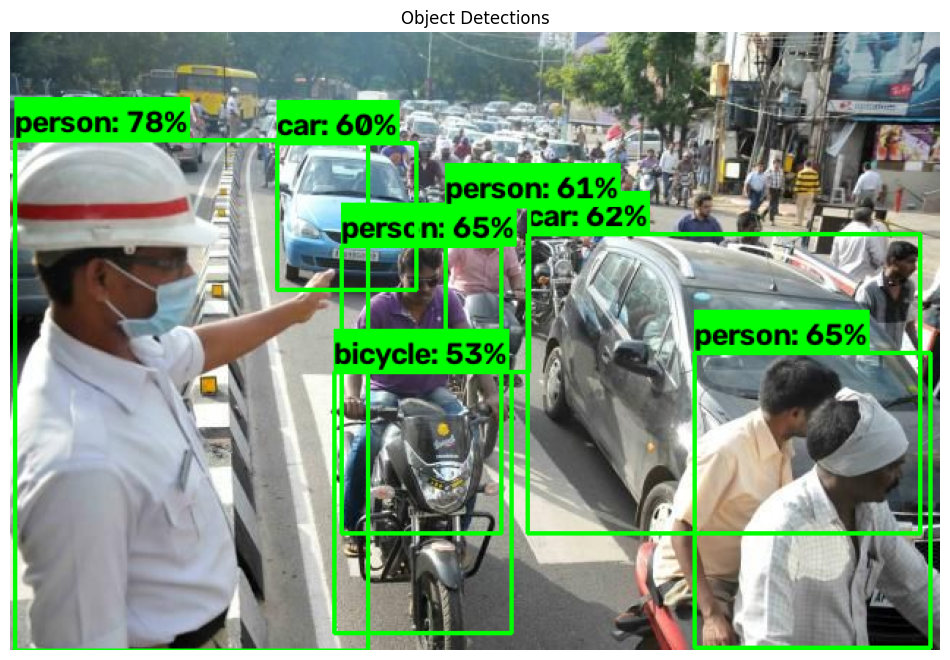

In [14]:
# Define a simple function to draw bounding boxes and labels
def draw_boxes_and_labels(image, boxes, classes, scores, num_detections, category_index, min_score_thresh=0.5):
    image_copy = np.copy(image)
    im_height, im_width, _ = image_copy.shape

    for i in range(num_detections):
        if scores[i] > min_score_thresh:
            ymin, xmin, ymax, xmax = boxes[i]
            ymin = int(ymin * im_height)
            xmin = int(xmin * im_width)
            ymax = int(ymax * im_height)
            xmax = int(xmax * im_width)

            # Get class name (using a placeholder for now)
            class_name = category_index.get(int(classes[i]), {'name': 'N/A'})['name']
            label = f'{class_name}: {int(scores[i]*100)}%'

            # Draw bounding box
            cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(image_copy, (xmin, ymin - h - 10), (xmin + w, ymin), (0, 255, 0), -1)
            cv2.putText(image_copy, label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    return image_copy

# Placeholder for COCO class names (a subset for common objects)
# In a real application, you'd load the full COCO label map.
category_index = {
    1: {'id': 1, 'name': 'person'},
    2: {'id': 2, 'name': 'bicycle'},
    3: {'id': 3, 'name': 'car'},
    4: {'id': 4, 'name': 'motorcycle'},
    5: {'id': 5, 'name': 'airplane'},
    # ... add more as needed based on COCO dataset
    15: {'id': 15, 'name': 'cat'},
    16: {'id': 16, 'name': 'dog'},
    17: {'id': 17, 'name': 'horse'},
    18: {'id': 18, 'name': 'sheep'},
    19: {'id': 19, 'name': 'cow'},
    20: {'id': 20, 'name': 'elephant'},
    21: {'id': 21, 'name': 'bear'}
}

# Draw results on the image
image_with_detections = draw_boxes_and_labels(image_np, boxes, class_ids, scores, num_detections, category_index)

# Display the image with detections
plt.figure(figsize=(12, 10))
plt.imshow(image_with_detections)
plt.axis('off')
plt.title('Object Detections')
plt.show()